# CALVIN Dataset Exploration
Load a few data points, inspect their structure, and visualize first/last frames with action trajectories.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from config import (
    TRAIN_DIR, VAL_DIR, IMAGE_KEY, ACTION_KEY,
    EPISODE_TEMPLATE, LANG_ANNOTATIONS_SUBDIR, LANG_ANNOTATIONS_FILE,
)
from utils import load_calvin_to_dataframe, extract_verb
import os

## 1. Load language annotations into a DataFrame

In [16]:
df = load_calvin_to_dataframe(TRAIN_DIR)
df = df.sort_values('primary_verb').reset_index(drop=True)
print(f"Total annotated episodes: {len(df)}")
print(f"Unique verbs: {df['primary_verb'].nunique()}")
print()

df.to_csv("calvin_train_annotations.csv", index=False)
print("Saved to calvin_train_annotations.csv")
print()
df.head(100)

Total annotated episodes: 3070
Unique verbs: 25

Saved to calvin_train_annotations.csv



,start_idx,end_idx,instruction,verbs,primary_verb
0,551166,551230,close the cabinet drawer,[close],close
1,558944,558981,close the drawer,[close],close
2,341612,341676,close the cabinet drawer,[close],close
3,552402,552466,close the cabinet drawer,[close],close
4,482546,482610,close the drawer,[close],close
...,...,...,...,...,...
95,381285,381349,grasp the red block from the drawer,[grasp],grasp
96,281334,281398,grasp the blue block lying in the slider,[grasp],grasp
97,271722,271786,grasp the pink block lying in the drawer,[grasp],grasp
98,496727,496791,grasp the pink block lying in the sliding cabinet,[grasp],grasp


## 2. Verb distribution

primary_verb
push        445
pick up     393
rotate      334
slide       304
grasp       241
lift        177
place       147
sweep       139
put         134
turn on     105
turn off    100
move         84
stack        73
turn         66
take off     46
lift up      40
remove       38
pull         35
store        34
close        32
open         30
unstack      24
go           18
collapse     18
move up      13
Name: count, dtype: int64



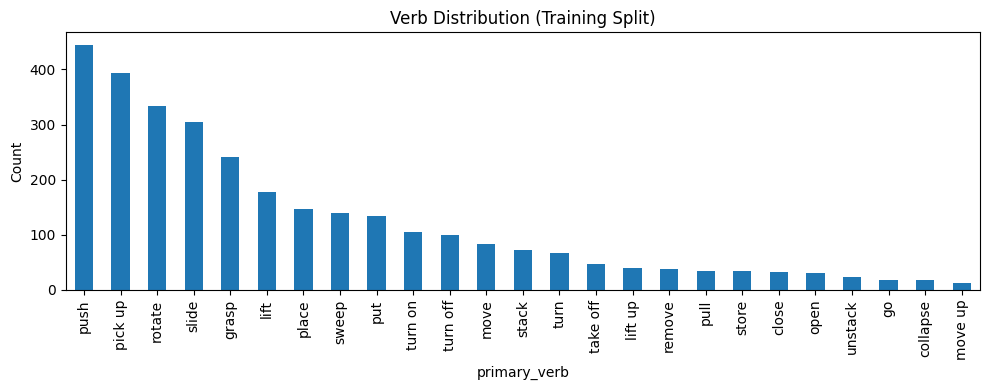

In [6]:
verb_counts = df['primary_verb'].value_counts()
print(verb_counts)
print()

fig, ax = plt.subplots(figsize=(10, 4))
verb_counts.plot.bar(ax=ax)
ax.set_ylabel("Count")
ax.set_title("Verb Distribution (Training Split)")
plt.tight_layout()
plt.show()

## 3. Inspect a single episode file

In [7]:
sample_row = df.iloc[0]
sample_path = os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(sample_row['start_idx']))
data = np.load(sample_path)

print("Keys in episode .npz file:")
for k in data.keys():
    print(f"  {k:20s} shape={str(data[k].shape):20s} dtype={data[k].dtype}")

Keys in episode .npz file:
  actions              shape=(7,)                 dtype=float64
  rel_actions          shape=(7,)                 dtype=float64
  robot_obs            shape=(15,)                dtype=float64
  scene_obs            shape=(24,)                dtype=float64
  rgb_static           shape=(200, 200, 3)        dtype=uint8
  rgb_gripper          shape=(84, 84, 3)          dtype=uint8
  rgb_tactile          shape=(160, 120, 6)        dtype=uint8
  depth_static         shape=(200, 200)           dtype=float32
  depth_gripper        shape=(84, 84)             dtype=float32
  depth_tactile        shape=(160, 120, 2)        dtype=float32


## 4. Visualize first & last frames for a few episodes

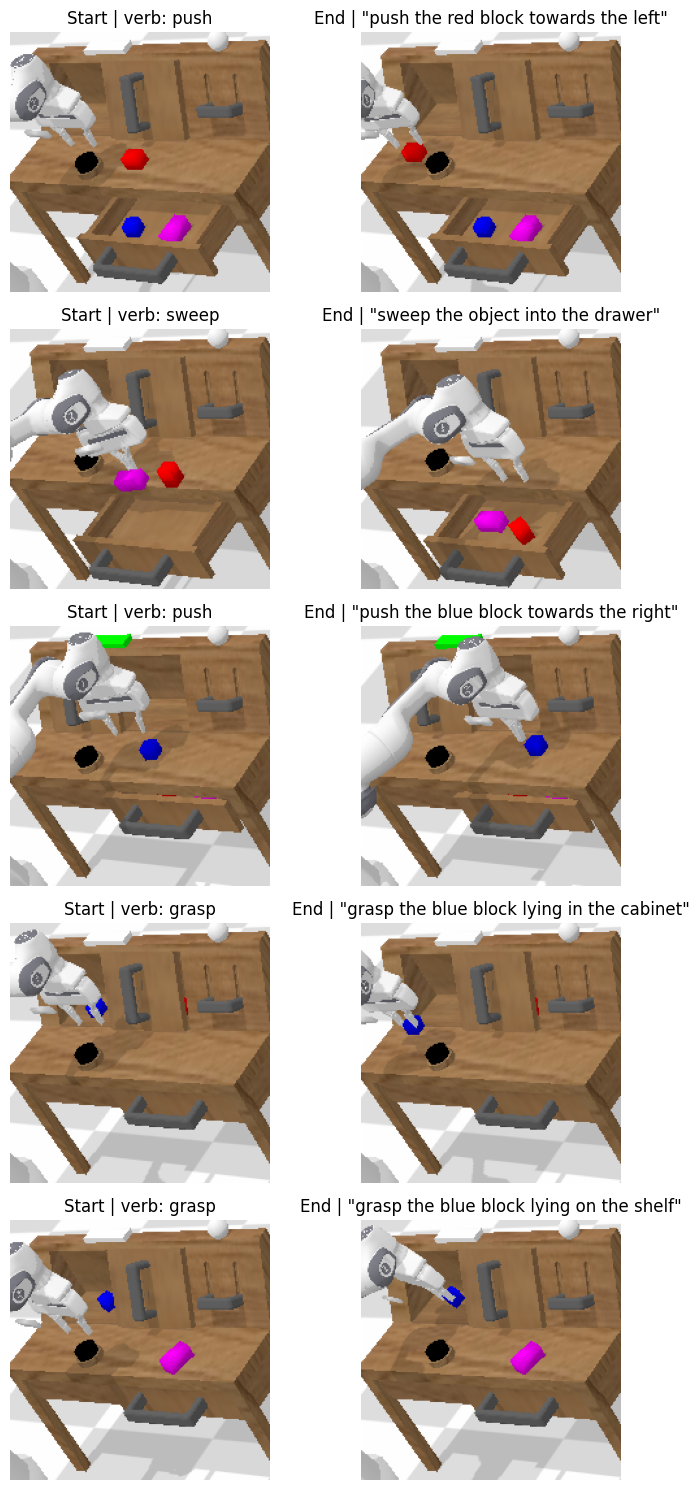

In [8]:
num_samples = 5
samples = df.sample(num_samples, random_state=42)

fig, axes = plt.subplots(num_samples, 2, figsize=(8, 3 * num_samples))

for i, (_, row) in enumerate(samples.iterrows()):
    start_img = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(row['start_idx'])))[IMAGE_KEY]
    end_img = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(row['end_idx'])))[IMAGE_KEY]

    axes[i, 0].imshow(start_img)
    axes[i, 0].set_title(f"Start | verb: {row['primary_verb']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(end_img)
    axes[i, 1].set_title(f"End | \"{row['instruction']}\"")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()



### 4b. Delta-patch visualization (top-K changed patches between first & last frame)
The model extracts ViT patch tokens from each frame, computes the L2 difference between
consecutive frames in embedding space, and keeps only the **top-K** patches with the
largest change. Here we approximate this in **pixel space** using the VC-1 grid
(patch_size=16, img resized to 224×224 → 14×14 = 196 patches, top-K=16).

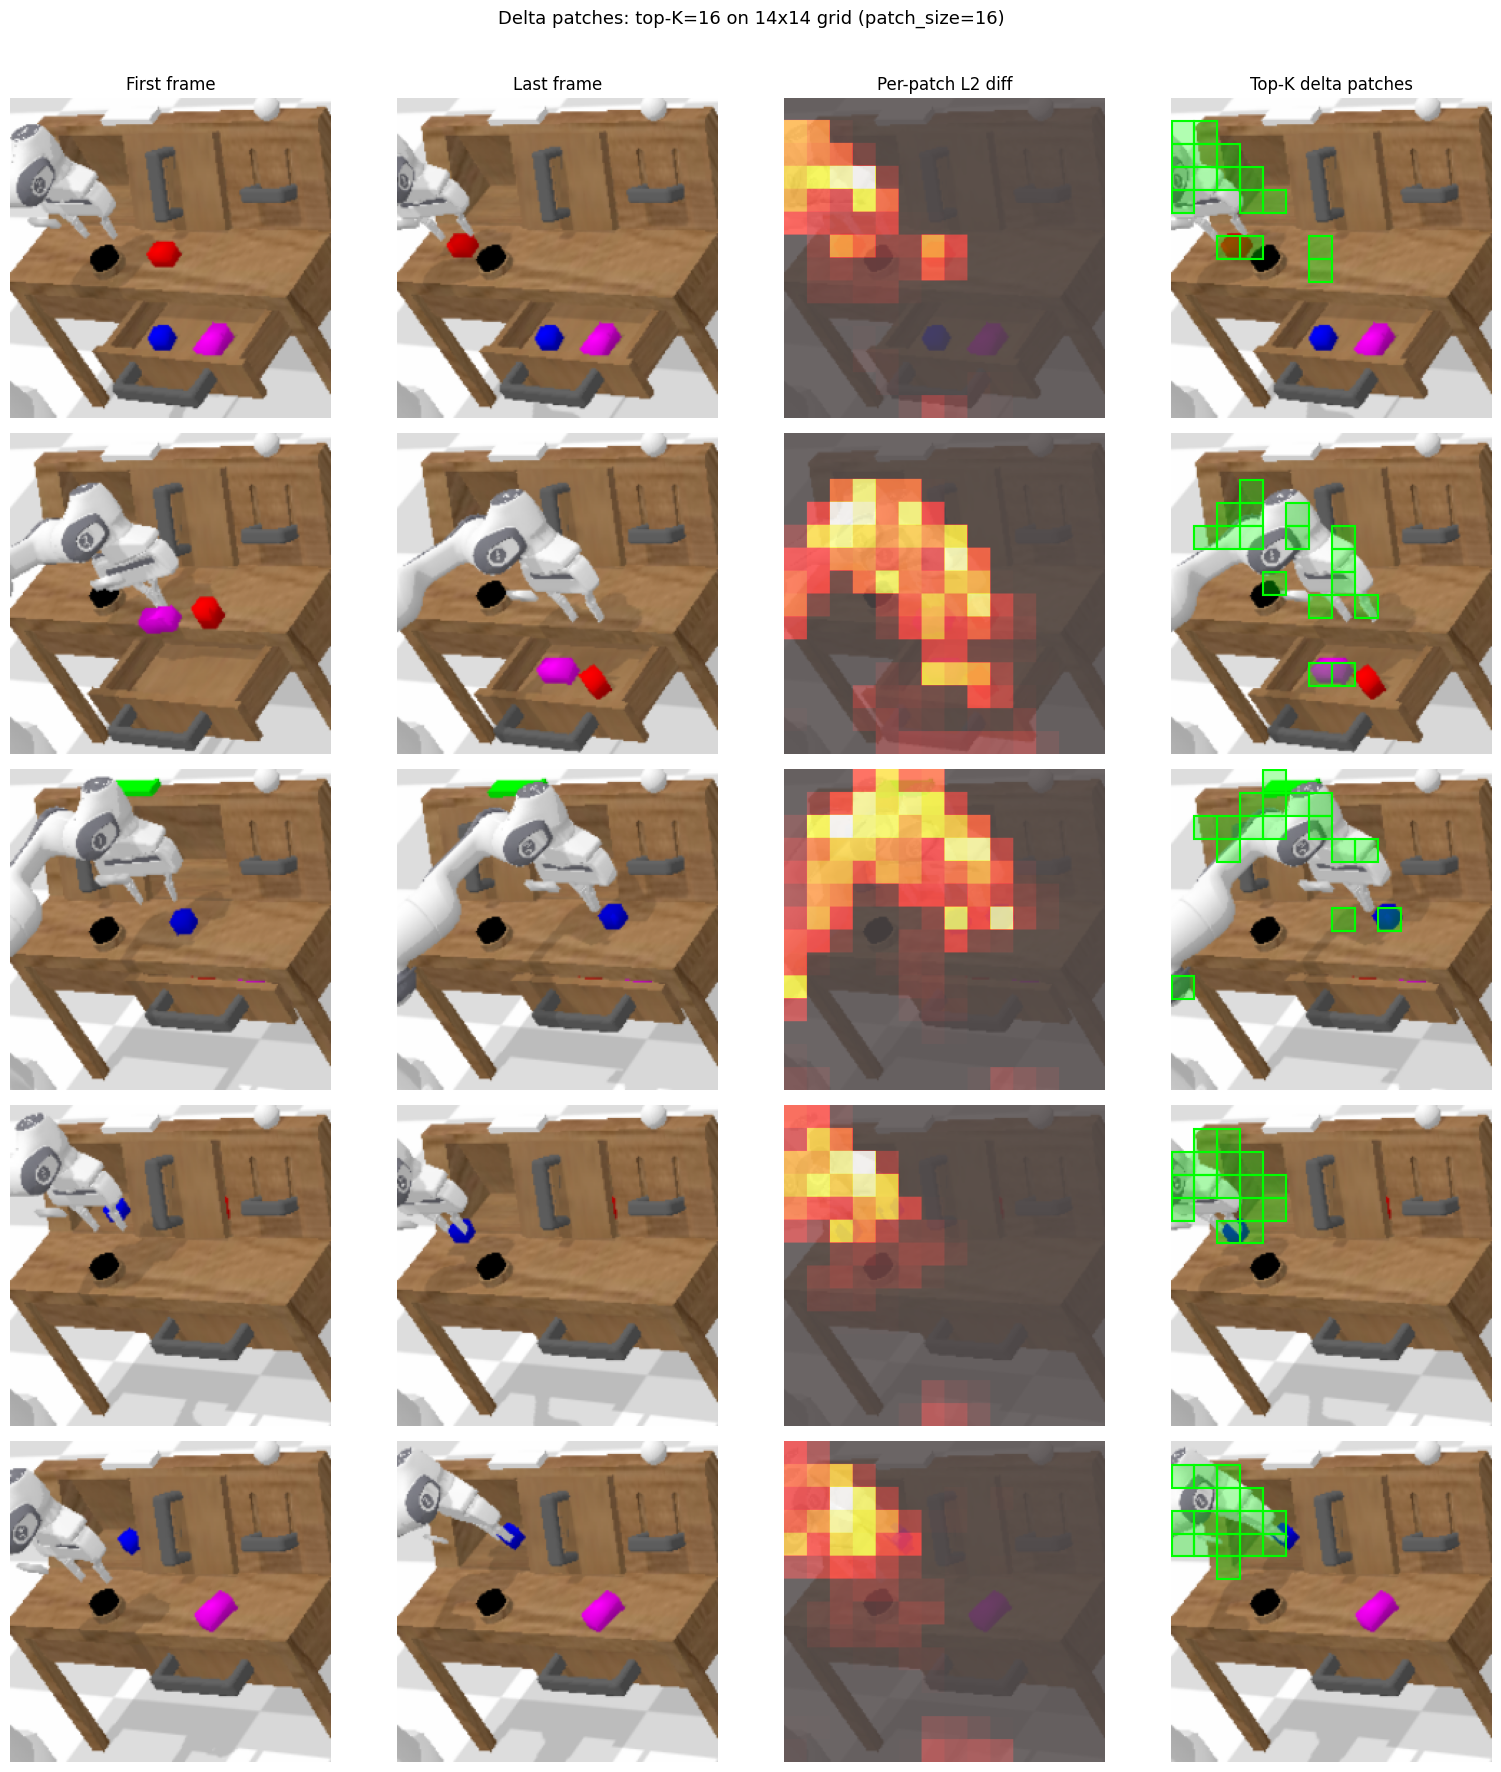

In [9]:
from PIL import Image

# Delta-patch parameters (matching VC-1 config)
PATCH_SIZE = 16
IMG_SIZE = 224
GRID = IMG_SIZE // PATCH_SIZE  # 14
K = 16  # top-K patches to keep

fig, axes = plt.subplots(num_samples, 4, figsize=(16, 3.5 * num_samples))
col_titles = ["First frame", "Last frame", "Per-patch L2 diff", "Top-K delta patches"]

for i, (_, row) in enumerate(samples.iterrows()):
    # Load and resize to 224x224 (matching model preprocessing)
    start_raw = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(row['start_idx'])))[IMAGE_KEY]
    end_raw = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(row['end_idx'])))[IMAGE_KEY]
    start_img = np.array(Image.fromarray(start_raw).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    end_img = np.array(Image.fromarray(end_raw).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))

    # Compute per-patch L2 difference in pixel space
    start_f = start_img.astype(np.float32) / 255.0
    end_f = end_img.astype(np.float32) / 255.0
    diff = end_f - start_f  # (224, 224, 3)

    patch_l2 = np.zeros((GRID, GRID))
    for r in range(GRID):
        for c in range(GRID):
            patch = diff[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE]
            patch_l2[r, c] = np.sqrt((patch ** 2).sum())

    # Top-K patch indices
    flat_idx = np.argsort(patch_l2.ravel())[::-1][:K]
    topk_rc = [(idx // GRID, idx % GRID) for idx in flat_idx]

    # Col 0: first frame
    axes[i, 0].imshow(start_img)
    axes[i, 0].axis("off")

    # Col 1: last frame
    axes[i, 1].imshow(end_img)
    axes[i, 1].axis("off")

    # Col 2: patch-level L2 heatmap overlaid on mean image
    mean_img = ((start_f + end_f) / 2 * 255).astype(np.uint8)
    axes[i, 2].imshow(mean_img, alpha=0.4)
    heatmap = axes[i, 2].imshow(
        np.kron(patch_l2, np.ones((PATCH_SIZE, PATCH_SIZE))),
        cmap="hot", alpha=0.6)
    axes[i, 2].axis("off")

    # Col 3: last frame with top-K patches highlighted
    axes[i, 3].imshow(end_img)
    for (r, c) in topk_rc:
        rect = plt.Rectangle(
            (c * PATCH_SIZE, r * PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
            linewidth=1.5, edgecolor="lime", facecolor="lime", alpha=0.3)
        axes[i, 3].add_patch(rect)
        rect_border = plt.Rectangle(
            (c * PATCH_SIZE, r * PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
            linewidth=1.5, edgecolor="lime", facecolor="none")
        axes[i, 3].add_patch(rect_border)
    axes[i, 3].axis("off")

    # Row label
    axes[i, 0].set_ylabel(row['primary_verb'], fontsize=11, rotation=0,
                           labelpad=50, va="center")

# Column titles
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12)

plt.suptitle(f"Delta patches: top-K={K} on {GRID}x{GRID} grid (patch_size={PATCH_SIZE})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Plot action trajectories for those same episodes
Each trajectory is a sequence of 7D relative actions (dx, dy, dz, droll, dpitch, dyaw, gripper).

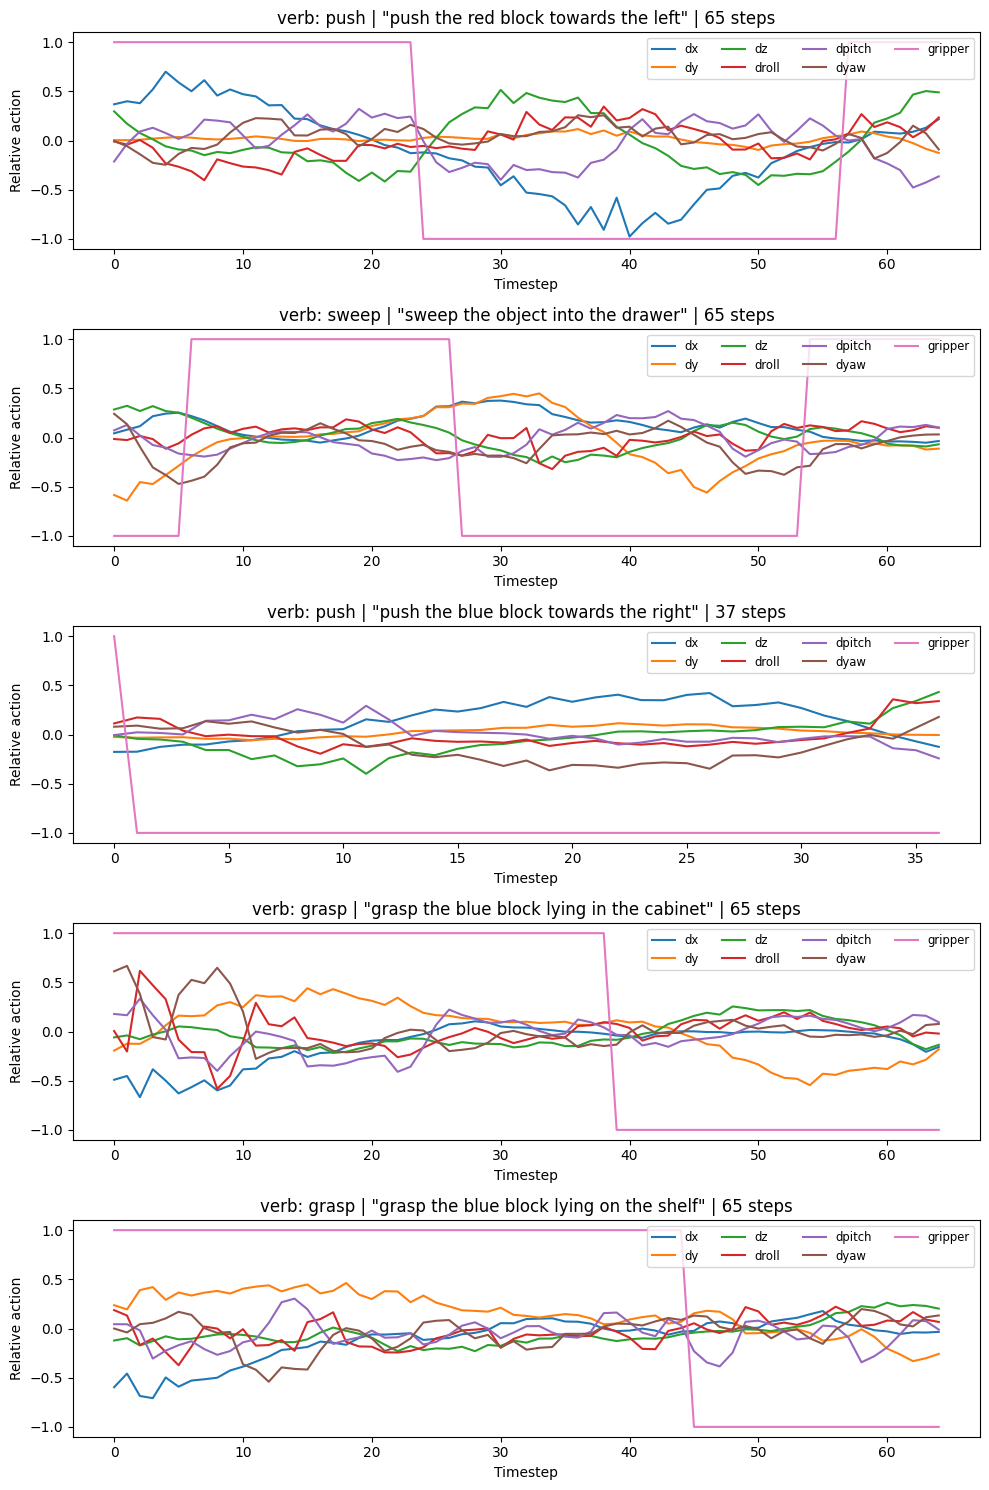

In [10]:
action_labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]

fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3 * num_samples))

for i, (_, row) in enumerate(samples.iterrows()):
    actions = []
    for idx in range(row['start_idx'], row['end_idx'] + 1):
        ep = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(idx)))
        actions.append(ep[ACTION_KEY])
    actions = np.array(actions)

    for dim in range(actions.shape[1]):
        axes[i].plot(actions[:, dim], label=action_labels[dim])
    axes[i].set_title(f"verb: {row['primary_verb']} | \"{row['instruction']}\" | {len(actions)} steps")
    axes[i].set_xlabel("Timestep")
    axes[i].set_ylabel("Relative action")
    axes[i].legend(loc="upper right", fontsize="small", ncol=4)

plt.tight_layout()
plt.show()

## 5b. Robot observations over time
`robot_obs` (15,): tcp_pos (3), tcp_orn (3), gripper_opening (1), arm_joint_states (7), gripper_action (1).

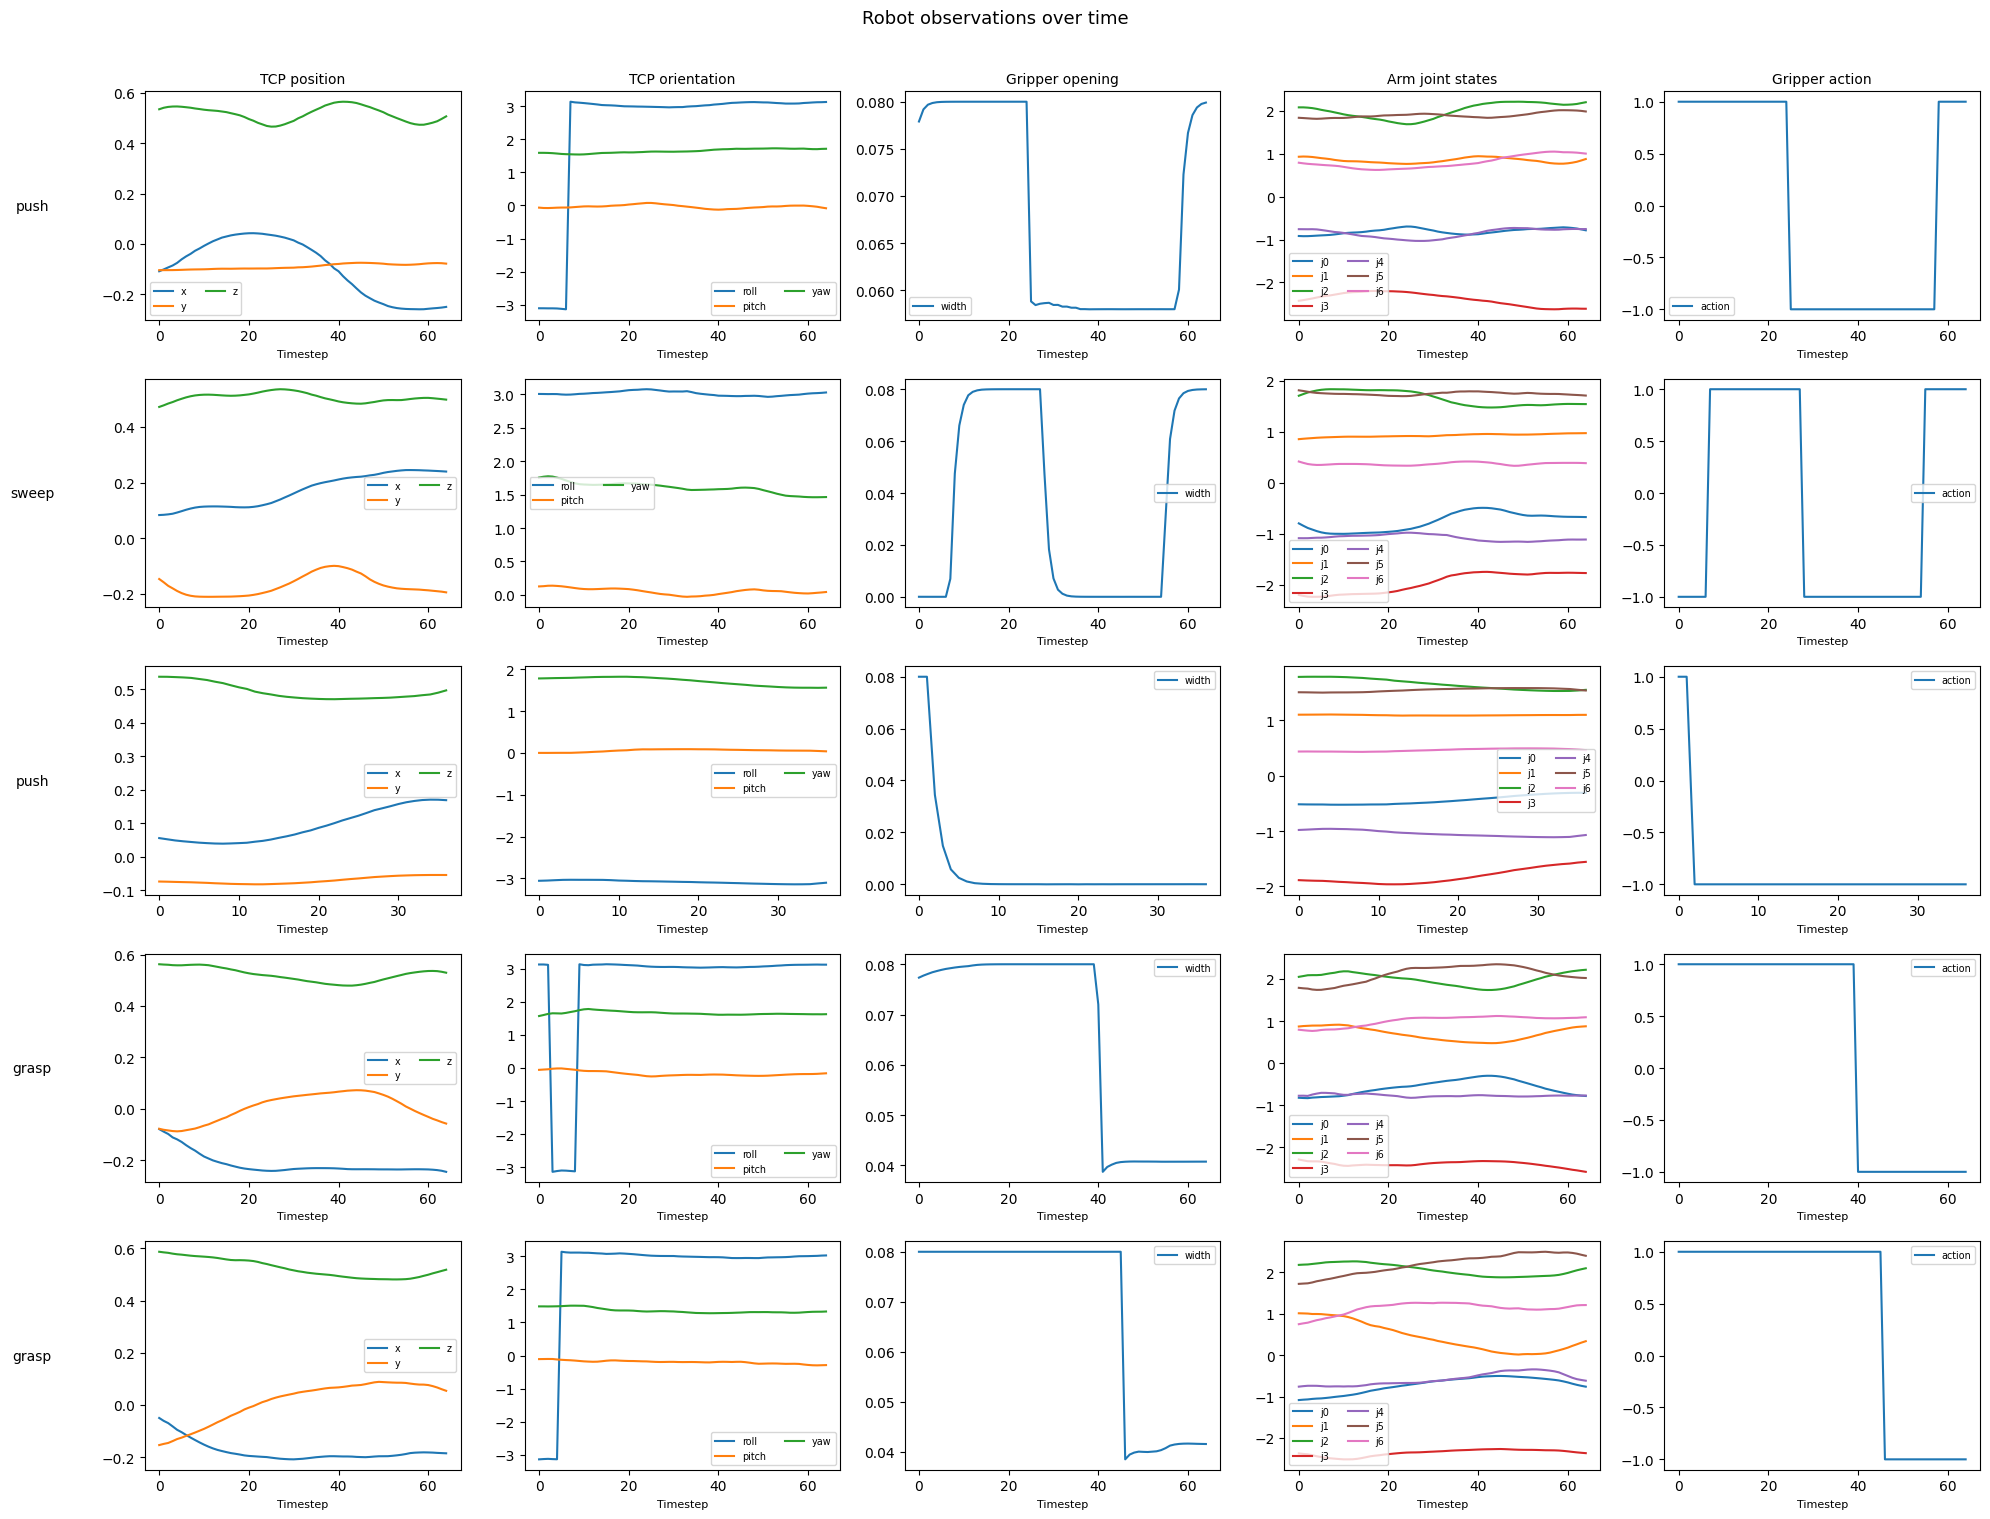

In [11]:
robot_obs_labels = {
    "TCP position": slice(0, 3),
    "TCP orientation": slice(3, 6),
    "Gripper opening": slice(6, 7),
    "Arm joint states": slice(7, 14),
    "Gripper action": slice(14, 15),
}
sub_labels = {
    "TCP position": ["x", "y", "z"],
    "TCP orientation": ["roll", "pitch", "yaw"],
    "Gripper opening": ["width"],
    "Arm joint states": [f"j{i}" for i in range(7)],
    "Gripper action": ["action"],
}

n_groups = len(robot_obs_labels)
fig, axes = plt.subplots(num_samples, n_groups, figsize=(4 * n_groups, 3 * num_samples),
                         squeeze=False)

for i, (_, row) in enumerate(samples.iterrows()):
    robot_obs_seq = []
    for idx in range(row['start_idx'], row['end_idx'] + 1):
        ep = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(idx)))
        robot_obs_seq.append(ep['robot_obs'])
    robot_obs_seq = np.array(robot_obs_seq)

    for j, (group_name, sl) in enumerate(robot_obs_labels.items()):
        data_slice = robot_obs_seq[:, sl]
        for k in range(data_slice.shape[1]):
            axes[i, j].plot(data_slice[:, k], label=sub_labels[group_name][k])
        axes[i, j].legend(fontsize="x-small", ncol=2)
        if i == 0:
            axes[i, j].set_title(group_name, fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(row['primary_verb'], fontsize=10,
                                   rotation=0, labelpad=50, va="center")
        axes[i, j].set_xlabel("Timestep", fontsize=8)

plt.suptitle("Robot observations over time", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5c. Scene observations over time
`scene_obs` (24,): sliding_door (1), drawer (1), button (1), switch (1), lightbulb (1), green_light (1), red_block pos+orn (6), blue_block pos+orn (6), pink_block pos+orn (6).

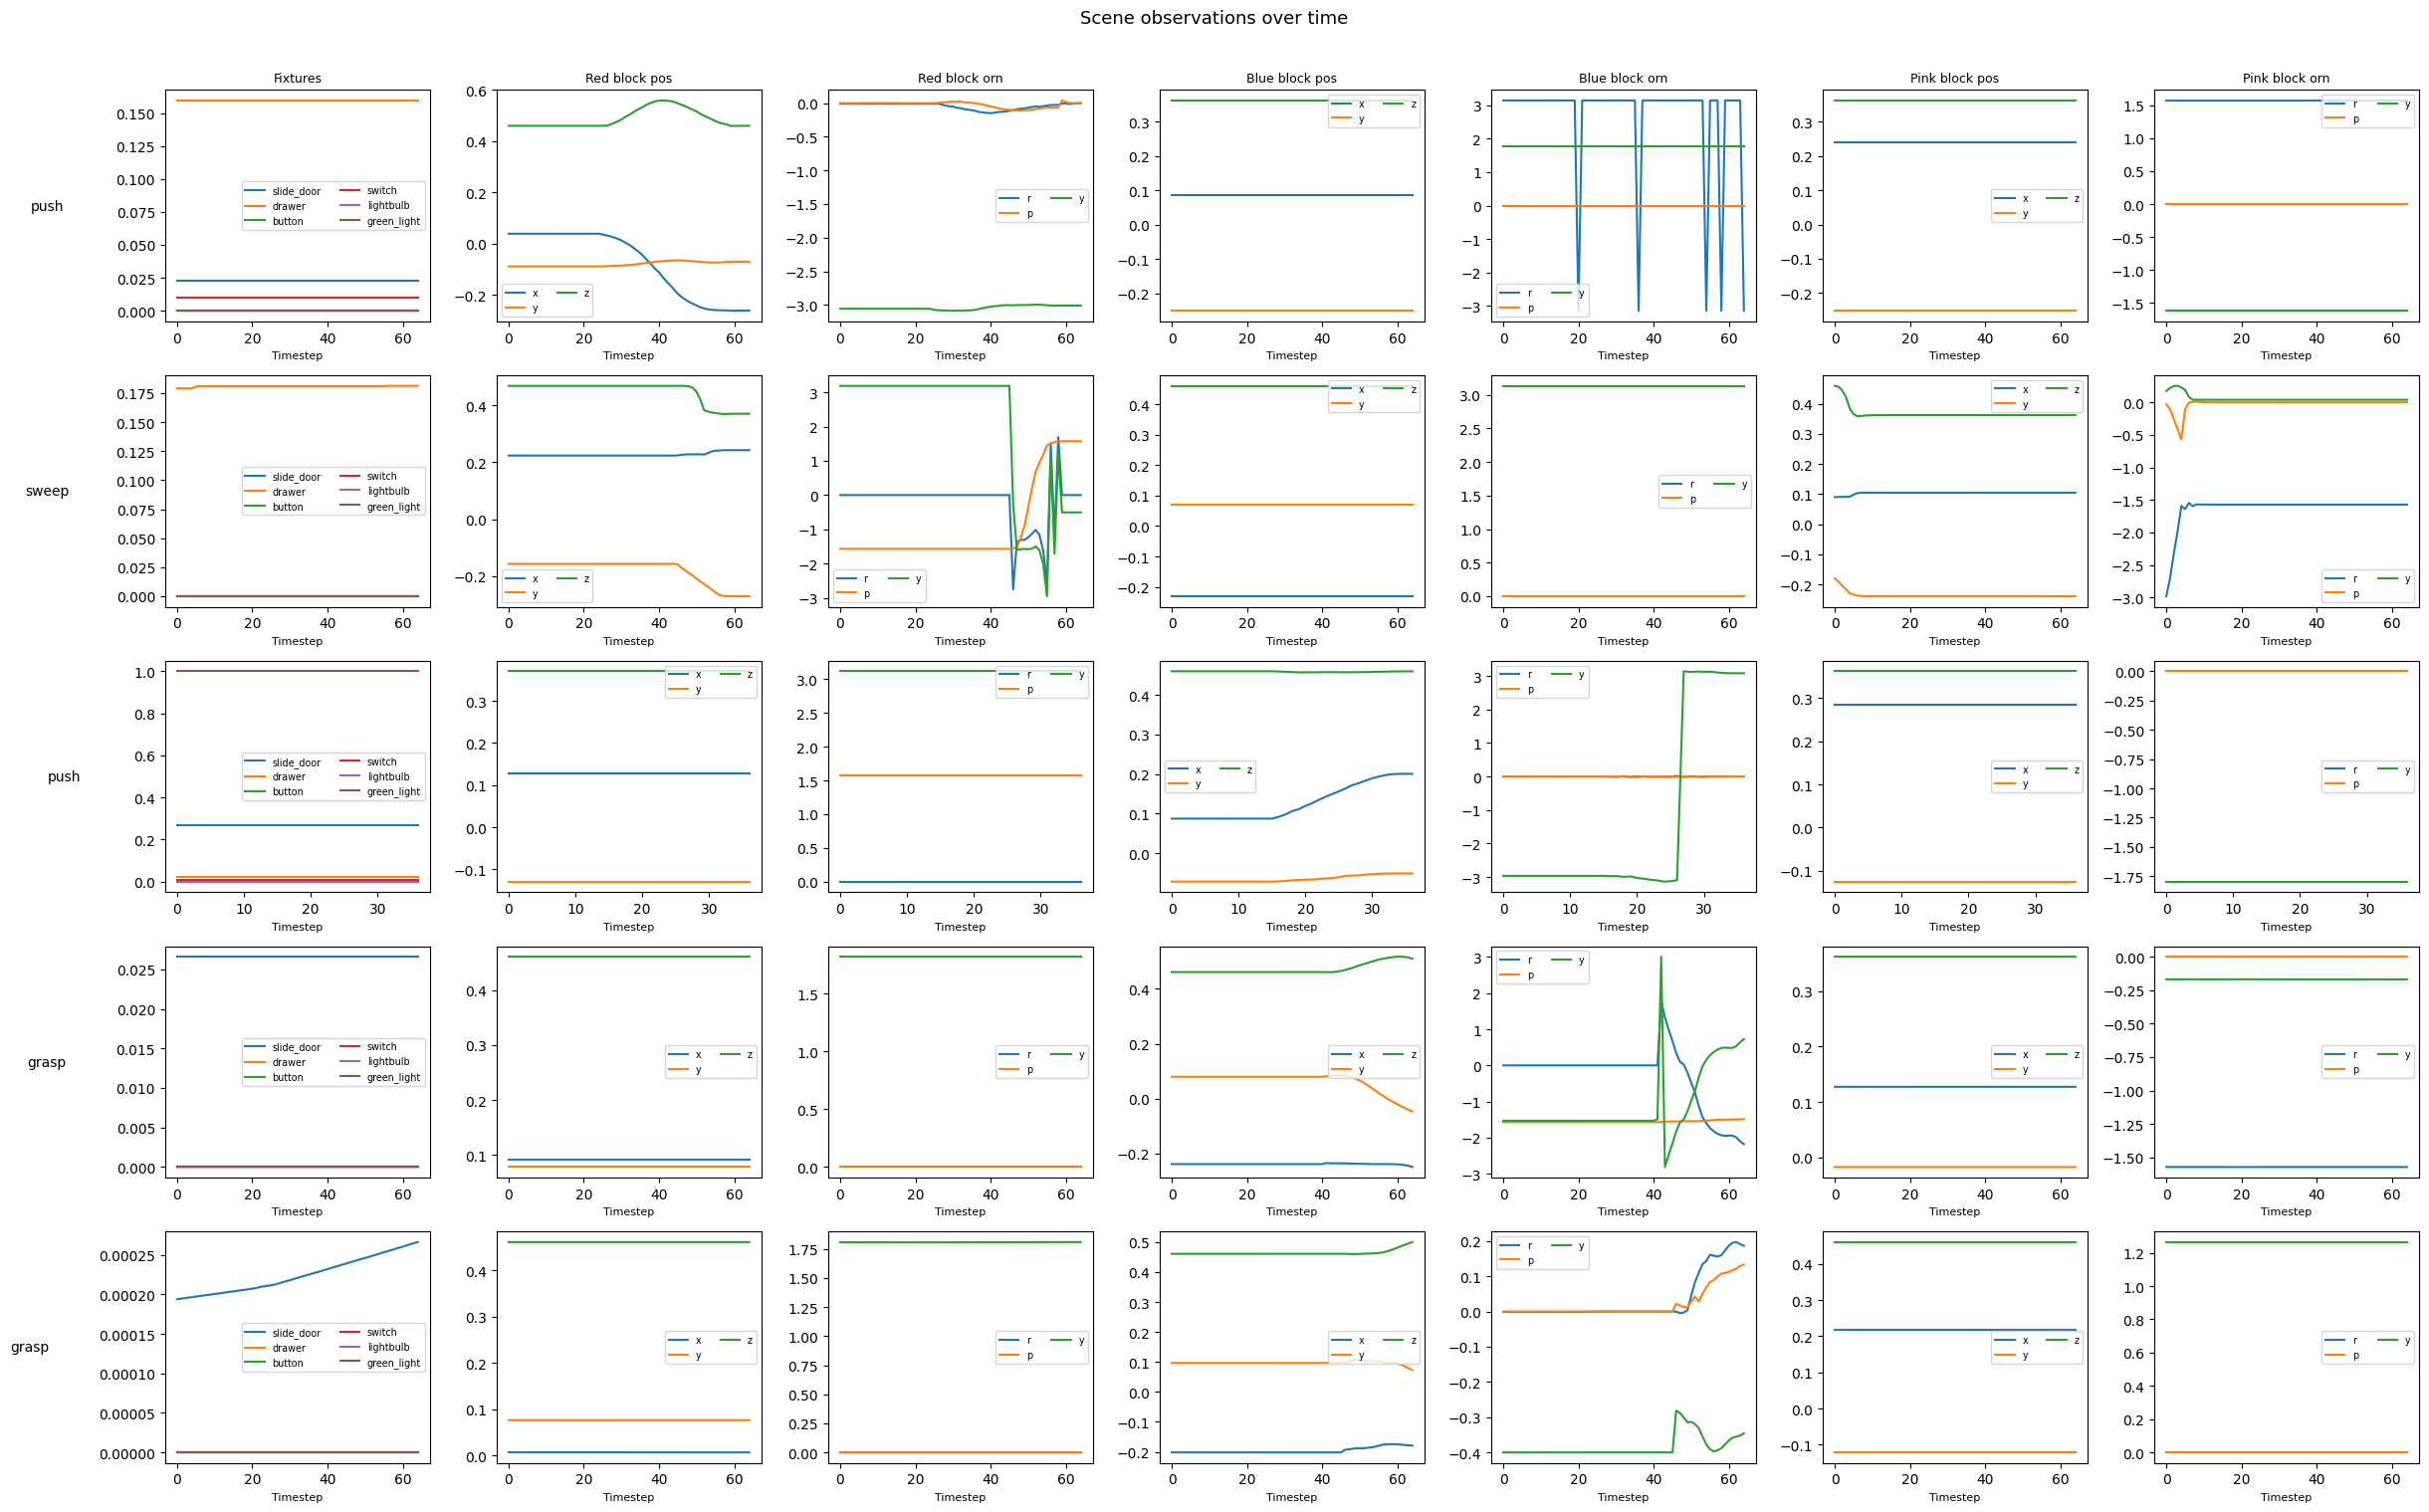

In [12]:
scene_obs_groups = {
    "Fixtures": {
        "indices": [0, 1, 2, 3, 4, 5],
        "labels": ["slide_door", "drawer", "button", "switch", "lightbulb", "green_light"],
    },
    "Red block pos": {"indices": [6, 7, 8], "labels": ["x", "y", "z"]},
    "Red block orn": {"indices": [9, 10, 11], "labels": ["r", "p", "y"]},
    "Blue block pos": {"indices": [12, 13, 14], "labels": ["x", "y", "z"]},
    "Blue block orn": {"indices": [15, 16, 17], "labels": ["r", "p", "y"]},
    "Pink block pos": {"indices": [18, 19, 20], "labels": ["x", "y", "z"]},
    "Pink block orn": {"indices": [21, 22, 23], "labels": ["r", "p", "y"]},
}

n_scene_groups = len(scene_obs_groups)
fig, axes = plt.subplots(num_samples, n_scene_groups,
                         figsize=(3.5 * n_scene_groups, 3 * num_samples),
                         squeeze=False)

for i, (_, row) in enumerate(samples.iterrows()):
    scene_obs_seq = []
    for idx in range(row['start_idx'], row['end_idx'] + 1):
        ep = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(idx)))
        scene_obs_seq.append(ep['scene_obs'])
    scene_obs_seq = np.array(scene_obs_seq)

    for j, (group_name, info) in enumerate(scene_obs_groups.items()):
        for k, col_idx in enumerate(info["indices"]):
            axes[i, j].plot(scene_obs_seq[:, col_idx], label=info["labels"][k])
        axes[i, j].legend(fontsize="x-small", ncol=2)
        if i == 0:
            axes[i, j].set_title(group_name, fontsize=9)
        if j == 0:
            axes[i, j].set_ylabel(row['primary_verb'], fontsize=10,
                                   rotation=0, labelpad=50, va="center")
        axes[i, j].set_xlabel("Timestep", fontsize=8)

plt.suptitle("Scene observations over time", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5d. Action trajectories (same episodes)
Split into translational (dx, dy, dz), rotational (droll, dpitch, dyaw), and gripper.

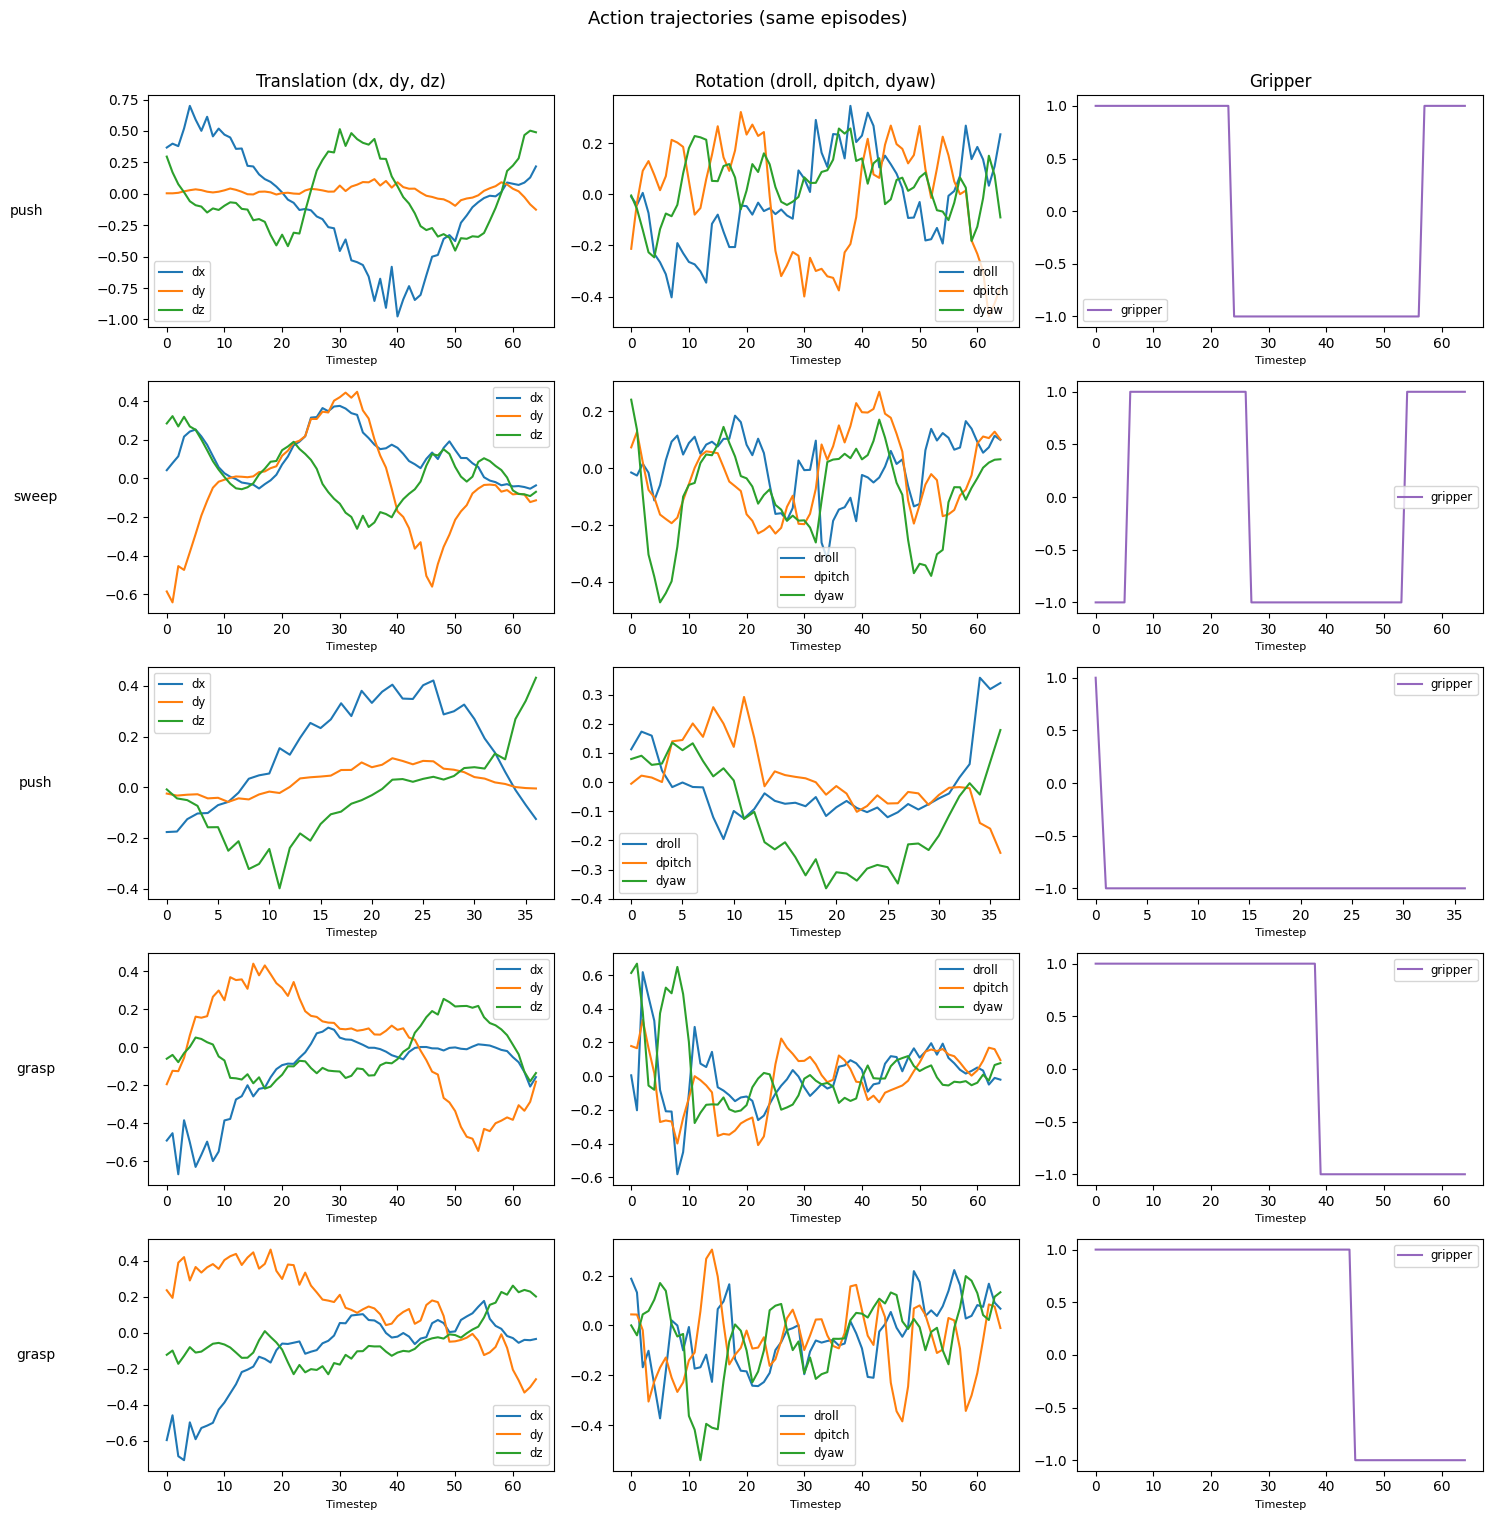

In [13]:
trans_labels = ["dx", "dy", "dz"]
rot_labels = ["droll", "dpitch", "dyaw"]

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 3 * num_samples), squeeze=False)

for i, (_, row) in enumerate(samples.iterrows()):
    actions = []
    for idx in range(row["start_idx"], row["end_idx"] + 1):
        ep = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(idx)))
        actions.append(ep[ACTION_KEY])
    actions = np.array(actions)

    # Translational
    for k in range(3):
        axes[i, 0].plot(actions[:, k], label=trans_labels[k])
    axes[i, 0].legend(fontsize="small")
    if i == 0:
        axes[i, 0].set_title("Translation (dx, dy, dz)")
    axes[i, 0].set_ylabel(row["primary_verb"], fontsize=10,
                            rotation=0, labelpad=50, va="center")

    # Rotational
    for k in range(3):
        axes[i, 1].plot(actions[:, 3 + k], label=rot_labels[k])
    axes[i, 1].legend(fontsize="small")
    if i == 0:
        axes[i, 1].set_title("Rotation (droll, dpitch, dyaw)")

    # Gripper
    axes[i, 2].plot(actions[:, 6], label="gripper", color="tab:purple")
    axes[i, 2].legend(fontsize="small")
    if i == 0:
        axes[i, 2].set_title("Gripper")

    for j in range(3):
        axes[i, j].set_xlabel("Timestep", fontsize=8)

plt.suptitle("Action trajectories (same episodes)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Sequence length distribution

Sequence length stats:
count    3070.000000
mean       59.812052
std         9.996229
min        34.000000
25%        65.000000
50%        65.000000
75%        65.000000
max        65.000000
Name: seq_len, dtype: float64



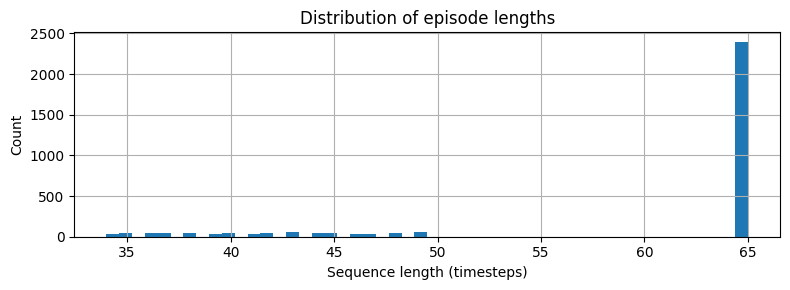

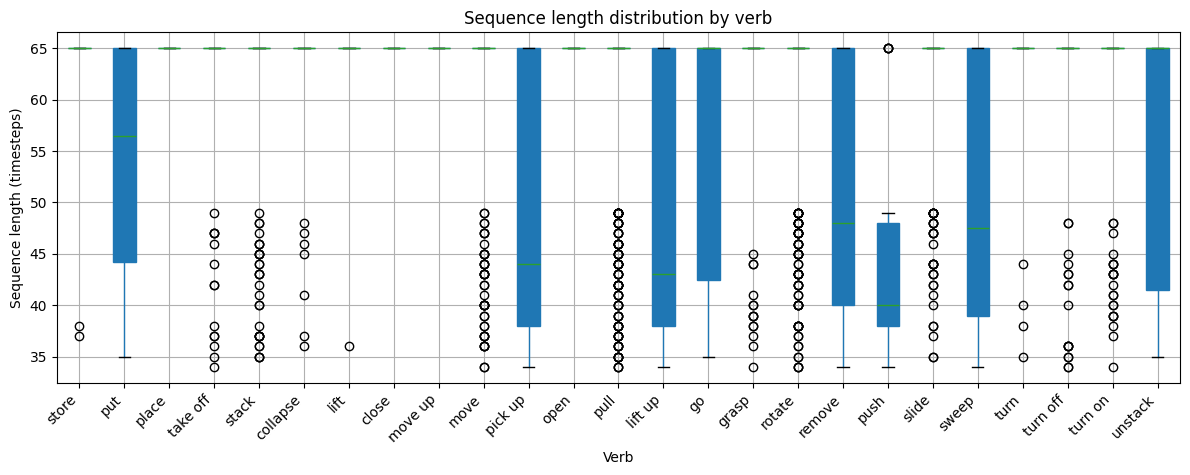

In [14]:
df['seq_len'] = df['end_idx'] - df['start_idx'] + 1

print(f"Sequence length stats:")
print(df['seq_len'].describe())
print()

fig, ax = plt.subplots(figsize=(8, 3))
df['seq_len'].hist(bins=50, ax=ax)
ax.set_xlabel("Sequence length (timesteps)")
ax.set_ylabel("Count")
ax.set_title("Distribution of episode lengths")
plt.tight_layout()
plt.show()

# Box plot of sequence length per verb
verb_order = df.groupby('primary_verb')['seq_len'].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column='seq_len', by='primary_verb', ax=ax,
           positions=range(len(verb_order)),
           showfliers=True, patch_artist=True)
ax.set_xticklabels(verb_order, rotation=45, ha='right')
ax.set_xlabel("Verb")
ax.set_ylabel("Sequence length (timesteps)")
ax.set_title("Sequence length distribution by verb")
fig.suptitle("")  # remove default pandas boxplot title
plt.tight_layout()
plt.show()